- Analysera data
- Dela upp data i träning och testset
- Träna en linjär regressionsmodell
- Vad får du för träningsscore?
- Vad får du för testscore?
- Varför skiljer sig träning och testscore?
- Rita ut linjen som modellen skapar


<class 'pandas.DataFrame'>
RangeIndex: 4598 entries, 0 to 4597
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   price          4598 non-null   float64
 1   bedrooms       4598 non-null   float64
 2   bathrooms      4598 non-null   float64
 3   sqft_living    4598 non-null   int64  
 4   sqft_lot       4598 non-null   int64  
 5   floors         4598 non-null   float64
 6   waterfront     4598 non-null   int64  
 7   view           4598 non-null   int64  
 8   condition      4598 non-null   int64  
 9   sqft_above     4598 non-null   int64  
 10  sqft_basement  4598 non-null   int64  
 11  yr_built       4598 non-null   int64  
 12  yr_renovated   4598 non-null   int64  
 13  city           4598 non-null   str    
 14  statezip       4598 non-null   str    
 15  country        4598 non-null   str    
dtypes: float64(4), int64(9), str(3)
memory usage: 574.9 KB
None
              price     bedrooms  ...     yr_bu

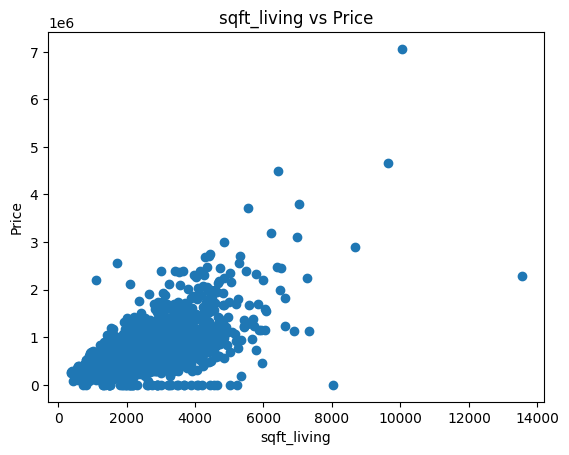

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import seaborn as sns

df= pd.read_csv('C:/Users/David Danell/Desktop/jupyter notebook/data collections/house_price.csv')

df.drop(columns='Unnamed: 0', inplace=True)

print(df.info())
print(df.describe())
print(df.shape)
print(df.nunique())
print(df.isna().sum())

#df.hist(figsize=(16,16))

plt.scatter(df["sqft_living"], df["price"])
plt.xlabel("sqft_living")
plt.ylabel("Price")
plt.title("sqft_living vs Price")
plt.show()

- Dela upp data i träning och testset
- Träna en linjär regressionsmodell

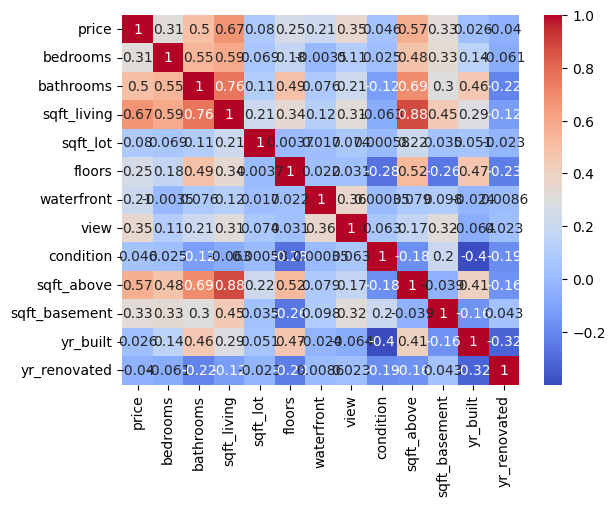

Train score 0.5276049345873336


In [ ]:
model= LinearRegression()

df= df
y=df.price

features= [
    'bedrooms',
    'bathrooms',
    'sqft_living',
	'sqft_lot',
	'floors',
	'waterfront',
	'view',
	'condition',
	'sqft_above',
	'sqft_basement',
	'yr_built',
	'yr_renovated'
    ]


df_corr= df[[
    'price',
	'bedrooms',
    'bathrooms',
    'sqft_living',
	'sqft_lot',
	'floors',
	'waterfront',
	'view',
	'condition',
	'sqft_above',
	'sqft_basement',
	'yr_built',
	'yr_renovated'
    ]].corr()

sns.heatmap(df_corr, annot=True, cmap='coolwarm')
plt.show()

X=df[features]

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1, test_size=0.2)

model.fit(X_train, y_train)





In [49]:
from sklearn.feature_selection import mutual_info_regression

# All discrete features should now have integer dtypes (double-check this before using MI!)
discrete_features = X.dtypes == int

print(X.describe().dtypes)

def make_mi_scores(X, y, discrete_features):
    mi_scores = mutual_info_regression(X, y, discrete_features=discrete_features)
    mi_scores = pd.Series(mi_scores, name="MI Scores", index=X.columns)
    mi_scores = mi_scores.sort_values(ascending=False)
    return mi_scores

mi_scores = make_mi_scores(X, y, discrete_features)
mi_scores[::] 

bedrooms         float64
bathrooms        float64
sqft_living      float64
sqft_lot         float64
floors           float64
waterfront       float64
view             float64
condition        float64
sqft_above       float64
sqft_basement    float64
yr_built         float64
yr_renovated     float64
dtype: object


sqft_living      0.298386
sqft_above       0.201695
bathrooms        0.191771
sqft_lot         0.146688
yr_built         0.075884
bedrooms         0.074537
floors           0.072027
view             0.049747
sqft_basement    0.039273
yr_renovated     0.013880
condition        0.012867
waterfront       0.005722
Name: MI Scores, dtype: float64

MAE: 165530.88998647805
Train score: 0.5276049345873336
Test Score: 0.5236993378173866


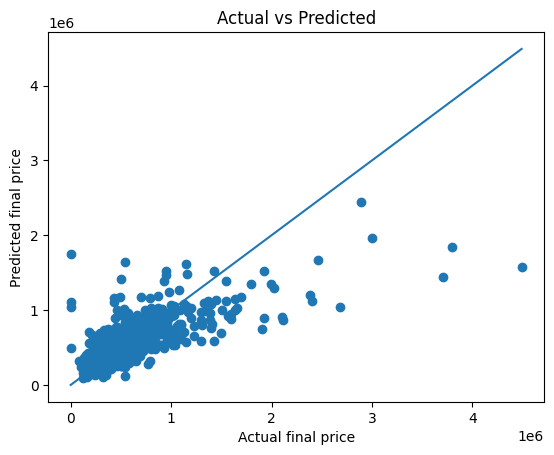

In [45]:
from sklearn.metrics import mean_absolute_error


predictions= model.predict(X_test)
print('MAE:', mean_absolute_error(y_test, predictions))

#training score:
train_score=model.score(X_train, y_train)
print('Train score:', train_score)

#test score: 
test_score= model.score(X_test, y_test)
print('Test Score:', test_score)




plt.scatter(y_test, predictions)

min_val = min(y_test.min(), predictions.min())
max_val = max(y_test.max(), predictions.max())

plt.plot([min_val, max_val], [min_val, max_val])

plt.xlabel("Actual final price")
plt.ylabel("Predicted final price")
plt.title("Actual vs Predicted")
plt.show()

